# Trader Performance vs Market Sentiment — Hyperliquid x Fear/Greed Index

**Primetrade.ai Data Science Intern — Round-0 Assignment**

This notebook analyzes how Bitcoin market sentiment (Fear/Greed Index) relates to trader
behavior and performance on Hyperliquid, using two datasets:

1. `fear_greed_index.csv` — daily BTC sentiment classification (2018–2025)
2. `historical_data.csv` — 211k+ individual trade executions across 32 accounts and 246
   coins (2023–2025)

Structure:
- **Part A** — Data preparation (load, clean, align, build metrics)
- **Part B** — Analysis (sentiment vs performance & behavior, segmentation)
- **Part C** — Actionable strategy recommendations
- **Bonus** — Behavioral archetype clustering


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

RAW_HIST = '../data_raw/historical_data.csv'   # place raw CSVs here, or point at your own path
RAW_FG = '../data_raw/fear_greed_index.csv'


## Part A — Data Preparation

### A.1 Load & document shape / missing values / duplicates

In [2]:
hist = pd.read_csv(RAW_HIST)
fg = pd.read_csv(RAW_FG)

print("historical_data.csv:", hist.shape[0], "rows x", hist.shape[1], "cols")
print("fear_greed_index.csv:", fg.shape[0], "rows x", fg.shape[1], "cols")
print()
print("Missing values (historical_data.csv):")
print(hist.isna().sum()[hist.isna().sum() > 0] if hist.isna().sum().sum() else "  none")
print("Missing values (fear_greed_index.csv):")
print(fg.isna().sum()[fg.isna().sum() > 0] if fg.isna().sum().sum() else "  none")
print()
print("Duplicate rows — historical_data.csv:", hist.duplicated().sum())
print("Duplicate rows — fear_greed_index.csv:", fg.duplicated().sum())


historical_data.csv: 211224 rows x 16 cols
fear_greed_index.csv: 2644 rows x 4 cols

Missing values (historical_data.csv):
  none
Missing values (fear_greed_index.csv):
  none

Duplicate rows — historical_data.csv: 0
Duplicate rows — fear_greed_index.csv: 0


**Result:** both files are clean — zero missing values, zero duplicate rows.

**Note on the `leverage` field:** the assignment description mentions a leverage column,
but this Hyperliquid export does not include one (no margin/equity field exists to derive
it). We use **position notional (Size USD)** as a proxy for trade risk/intensity instead,
and flag this substitution throughout.

### A.2 Convert timestamps & align datasets by date

In [3]:
hist['dt'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist['date'] = hist['dt'].dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

sent_map = {'Extreme Fear': 'Fear', 'Fear': 'Fear', 'Neutral': 'Neutral',
            'Greed': 'Greed', 'Extreme Greed': 'Greed'}
fg['sentiment_simple'] = fg['classification'].map(sent_map)

print("historical_data.csv date range:", hist['date'].min(), "to", hist['date'].max())
print("fear_greed_index.csv date range:", fg['date'].min(), "to", fg['date'].max())

trades = hist.merge(fg[['date', 'classification', 'sentiment_simple', 'value']], on='date', how='left')
missing_sent = trades['sentiment_simple'].isna().sum()
print(f"Trades with no matching sentiment day: {missing_sent} ({missing_sent/len(trades)*100:.2f}%)")
trades = trades.dropna(subset=['sentiment_simple']).copy()
trades['is_realized'] = trades['Closed PnL'] != 0


historical_data.csv date range: 2023-05-01 to 2025-05-01
fear_greed_index.csv date range: 2018-02-01 to 2025-05-02
Trades with no matching sentiment day: 6 (0.00%)


### A.3 Build key metrics — account-day and day level

In [4]:
grp = trades.groupby(['Account', 'date'])
acct_day = grp.agg(
    n_trades=('Trade ID', 'count'),
    volume_usd=('Size USD', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    realized_pnl=('Closed PnL', 'sum'),
    fees=('Fee', 'sum'),
    n_buy=('Side', lambda s: (s == 'BUY').sum()),
    n_sell=('Side', lambda s: (s == 'SELL').sum()),
).reset_index()

realized = trades[trades['is_realized']]
win = realized.groupby(['Account', 'date']).apply(
    lambda d: pd.Series({'n_realized_trades': len(d), 'n_wins': (d['Closed PnL'] > 0).sum()}),
    include_groups=False
).reset_index()
win['win_rate'] = np.where(win['n_realized_trades'] > 0, win['n_wins'] / win['n_realized_trades'], np.nan)
acct_day = acct_day.merge(win[['Account', 'date', 'n_realized_trades', 'win_rate']], on=['Account', 'date'], how='left')

acct_day['long_short_ratio'] = np.where(acct_day['n_sell'] > 0, acct_day['n_buy'] / acct_day['n_sell'], np.nan)
acct_day['net_pnl_after_fees'] = acct_day['realized_pnl'] - acct_day['fees']

day_sent = fg[['date', 'classification', 'sentiment_simple', 'value']].drop_duplicates('date')
acct_day = acct_day.merge(day_sent, on='date', how='left')

print(f"Account-day rows: {len(acct_day):,}  |  unique accounts: {acct_day['Account'].nunique()}")
acct_day.head()


Account-day rows: 2,340  |  unique accounts: 32


In [5]:
day = trades.groupby('date').agg(
    n_trades=('Trade ID', 'count'),
    n_active_accounts=('Account', 'nunique'),
    total_volume_usd=('Size USD', 'sum'),
    total_realized_pnl=('Closed PnL', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    n_buy=('Side', lambda s: (s == 'BUY').sum()),
    n_sell=('Side', lambda s: (s == 'SELL').sum()),
).reset_index()
day['long_short_ratio'] = day['n_buy'] / day['n_sell']
day = day.merge(day_sent, on='date', how='left')

day_realized = realized.groupby('date').apply(
    lambda d: pd.Series({'win_rate': (d['Closed PnL'] > 0).mean()}), include_groups=False
).reset_index()
day = day.merge(day_realized, on='date', how='left')

print(f"Trading days: {len(day)}")
print(day['sentiment_simple'].value_counts())
day.head()


Trading days: 479
sentiment_simple
Greed      307
Fear       105
Neutral     67
Name: count, dtype: int64


## Part B — Analysis

### B.1 Does performance differ between Fear and Greed days?

In [6]:
order = ['Fear', 'Neutral', 'Greed']
colors = {'Fear': '#c0392b', 'Neutral': '#7f8c8d', 'Greed': '#27ae60'}

perf = acct_day.groupby('sentiment_simple', observed=True).agg(
    avg_daily_pnl=('realized_pnl', 'mean'),
    median_daily_pnl=('realized_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    pnl_std=('realized_pnl', 'std'),
    n_obs=('realized_pnl', 'count'),
).round(2).loc[order]
display(perf)

dd = acct_day.groupby('sentiment_simple', observed=True)['realized_pnl'].quantile(0.05).round(2).loc[order]
print("5th percentile daily PnL (drawdown proxy):")
print(dd)


                  avg_daily_pnl  median_daily_pnl  ...   pnl_std  n_obs
sentiment_simple                                   ...                 
Fear                    5185.15            122.74  ...  31224.15    790
Neutral                 3438.62            167.55  ...  17447.86    376
Greed                   4144.21            265.25  ...  29252.04   1174

[3 rows x 5 columns]
5th percentile daily PnL (drawdown proxy):
sentiment_simple
Fear      -3484.97
Neutral    -884.53
Greed      -173.78
Name: realized_pnl, dtype: float64


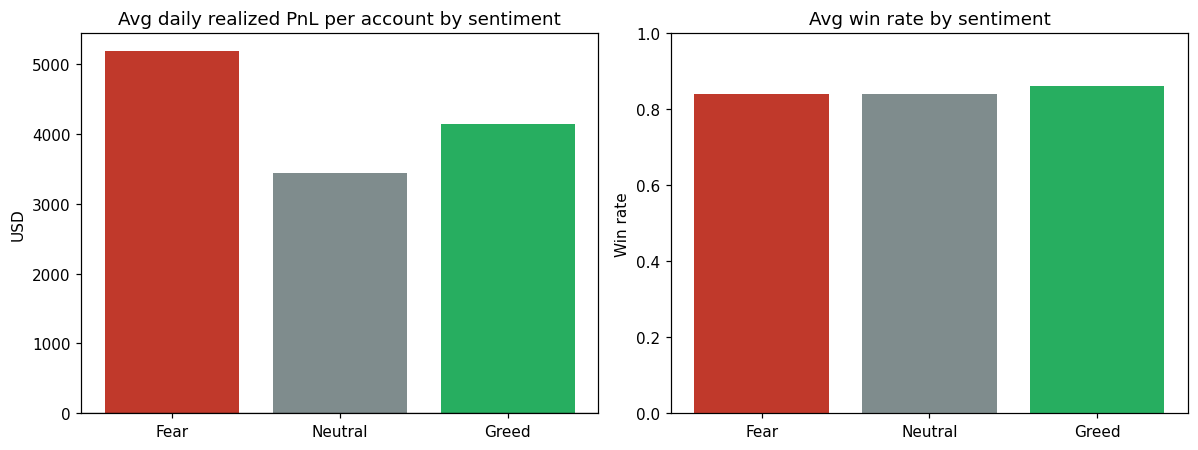

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(order, perf['avg_daily_pnl'], color=[colors[o] for o in order])
axes[0].set_title('Avg daily realized PnL per account by sentiment')
axes[0].set_ylabel('USD'); axes[0].axhline(0, color='black', lw=0.8)

axes[1].bar(order, perf['avg_win_rate'], color=[colors[o] for o in order])
axes[1].set_title('Avg win rate by sentiment')
axes[1].set_ylabel('Win rate'); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()


**Reading:** average daily PnL is actually higher on Fear days than Greed days, but so is
the standard deviation and the tail risk — the 5th-percentile (worst-case) daily PnL is
roughly **20x deeper** on Fear days (~ -$3,485) than on Greed days (~ -$174). In other
words, Fear days show a fatter, more volatile PnL distribution: bigger wins *and* bigger
losses, not simply "better" performance. Median PnL (less skewed by outliers) is actually
**lower** on Fear days than Greed days, which is the more representative comparison.

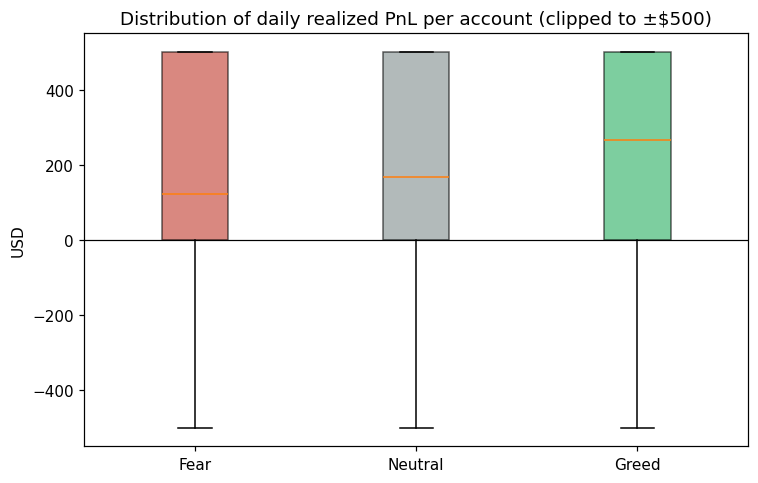

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
clip = acct_day['realized_pnl'].clip(-500, 500)
data_box = [clip[acct_day['sentiment_simple'] == s] for s in order]
bp = ax.boxplot(data_box, tick_labels=order, patch_artist=True, showfliers=False)
for patch, o in zip(bp['boxes'], order):
    patch.set_facecolor(colors[o]); patch.set_alpha(0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Distribution of daily realized PnL per account (clipped to ±$500)')
ax.set_ylabel('USD')
plt.tight_layout(); plt.show()


### B.2 Do traders change behavior based on sentiment?

                  avg_trades_per_acct_day  ...  avg_volume_usd
sentiment_simple                           ...                
Fear                               105.36  ...       756720.32
Neutral                            100.23  ...       479367.19
Greed                               76.91  ...       351829.35

[3 rows x 4 columns]


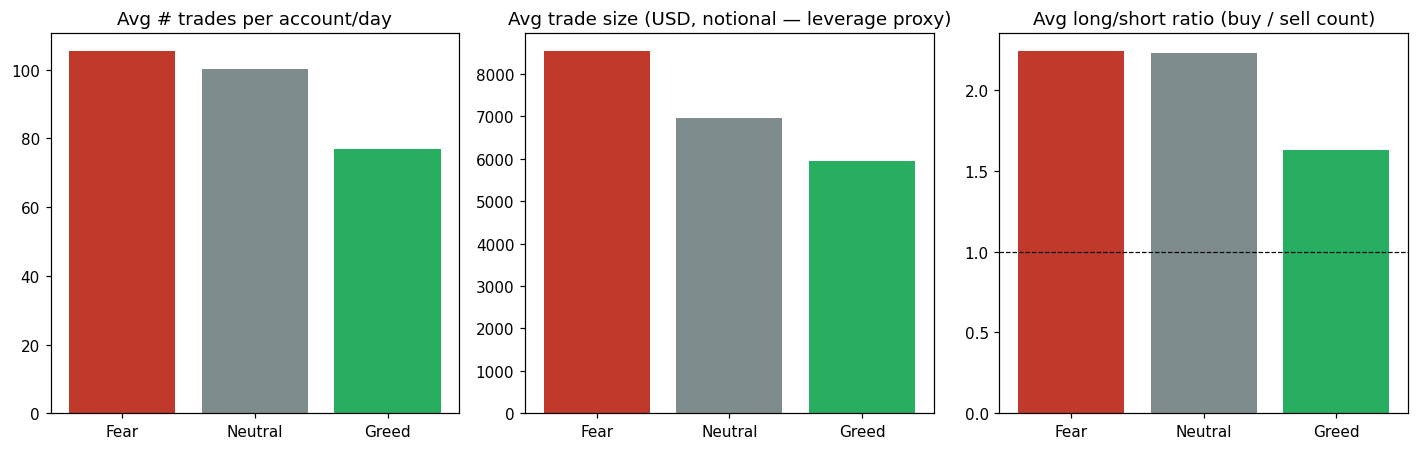

In [9]:
behav = acct_day.groupby('sentiment_simple', observed=True).agg(
    avg_trades_per_acct_day=('n_trades', 'mean'),
    avg_trade_size_usd=('avg_trade_size_usd', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean'),
    avg_volume_usd=('volume_usd', 'mean'),
).round(2).loc[order]
display(behav)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].bar(order, behav['avg_trades_per_acct_day'], color=[colors[o] for o in order])
axes[0].set_title('Avg # trades per account/day')
axes[1].bar(order, behav['avg_trade_size_usd'], color=[colors[o] for o in order])
axes[1].set_title('Avg trade size (USD, notional — leverage proxy)')
axes[2].bar(order, behav['avg_long_short_ratio'], color=[colors[o] for o in order])
axes[2].axhline(1, color='black', lw=0.8, ls='--')
axes[2].set_title('Avg long/short ratio (buy / sell count)')
plt.tight_layout(); plt.show()


**Reading:** on Fear days traders place **larger** trades (higher notional, our leverage
proxy) and trade **more often** than on Greed days, and lean more heavily long (buy/sell
ratio ~2.2 vs ~1.6). This is a *risk-on-into-weakness* pattern — traders are sizing up and
buying more aggressively exactly when sentiment is worst, which is consistent with the
fatter PnL tails seen above.

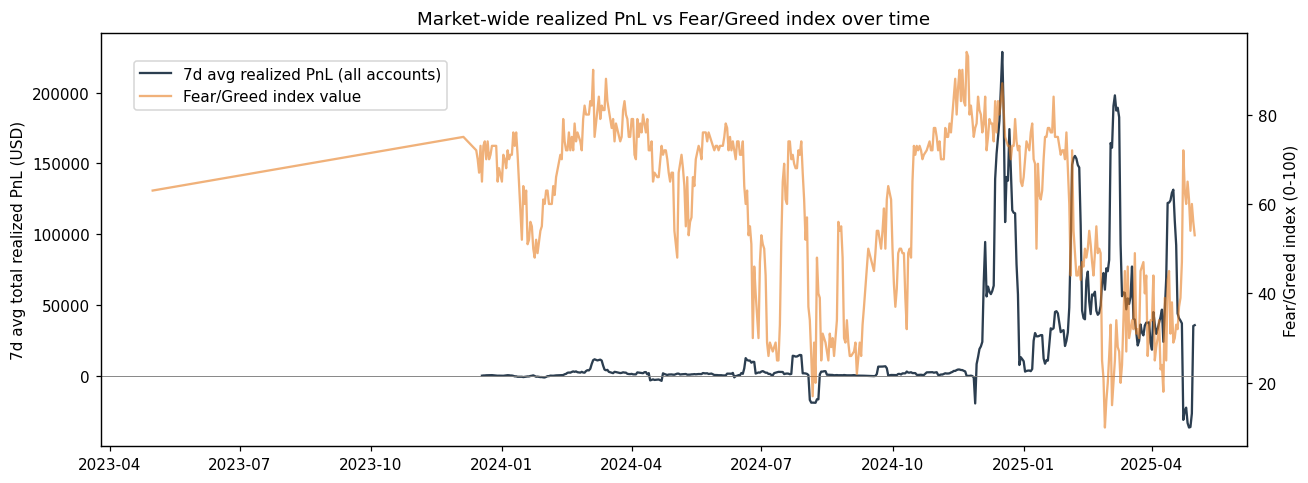

In [10]:
day_sorted = day.sort_values('date')
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(pd.to_datetime(day_sorted['date']), day_sorted['total_realized_pnl'].rolling(7).mean(),
         color='#2c3e50', label='7d avg realized PnL (all accounts)')
ax1.set_ylabel('7d avg total realized PnL (USD)'); ax1.axhline(0, color='grey', lw=0.6)
ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(day_sorted['date']), day_sorted['value'], color='#e67e22', alpha=0.6,
         label='Fear/Greed index value')
ax2.set_ylabel('Fear/Greed index (0-100)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
ax1.set_title('Market-wide realized PnL vs Fear/Greed index over time')
plt.tight_layout(); plt.show()


### B.3 Segmentation

In [11]:
acct_summary = acct_day.groupby('Account').agg(
    total_pnl=('realized_pnl', 'sum'),
    avg_trade_size=('avg_trade_size_usd', 'mean'),
    avg_daily_trades=('n_trades', 'mean'),
    active_days=('date', 'nunique'),
    avg_win_rate=('win_rate', 'mean'),
    pnl_std=('realized_pnl', 'std'),
).reset_index()
acct_summary['size_segment'] = pd.qcut(acct_summary['avg_trade_size'], 2, labels=['Low size', 'High size'])
acct_summary['freq_segment'] = pd.qcut(acct_summary['avg_daily_trades'], 2, labels=['Infrequent', 'Frequent'])
acct_summary['consistency'] = acct_summary['pnl_std'] / acct_summary['total_pnl'].abs().replace(0, np.nan)
acct_summary['consistency_segment'] = np.where(
    acct_summary['total_pnl'] > 0,
    np.where(acct_summary['consistency'] < acct_summary['consistency'].median(), 'Consistent winner', 'Inconsistent winner'),
    'Net loser'
)

seg_size = acct_day.merge(acct_summary[['Account', 'size_segment']], on='Account').groupby(
    ['size_segment', 'sentiment_simple'], observed=True)['realized_pnl'].mean().unstack()[order].round(2)
seg_freq = acct_day.merge(acct_summary[['Account', 'freq_segment']], on='Account').groupby(
    ['freq_segment', 'sentiment_simple'], observed=True)['realized_pnl'].mean().unstack()[order].round(2)

print("Avg daily PnL — trade-size segment x sentiment:")
display(seg_size)
print("Avg daily PnL — frequency segment x sentiment:")
display(seg_freq)
print("Consistency segment counts:")
print(acct_summary['consistency_segment'].value_counts())


Avg daily PnL — trade-size segment x sentiment:
sentiment_simple     Fear  Neutral    Greed
size_segment                               
Low size          2575.66  2655.21  4589.85
High size         9540.18  4837.14  3347.14
Avg daily PnL — frequency segment x sentiment:
sentiment_simple     Fear  Neutral    Greed
freq_segment                               
Infrequent        2524.84  2891.88  3590.23
Frequent          7955.44  4130.28  4942.35
Consistency segment counts:
consistency_segment
Consistent winner      16
Inconsistent winner    13
Net loser               3
Name: count, dtype: int64


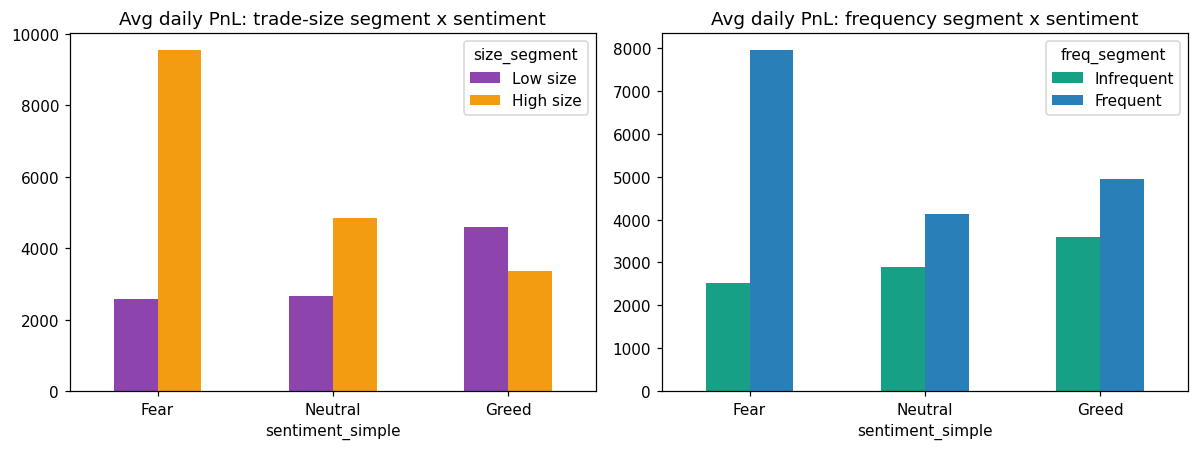

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
seg_size.T.plot(kind='bar', ax=axes[0], color=['#8e44ad', '#f39c12'])
axes[0].set_title('Avg daily PnL: trade-size segment x sentiment'); axes[0].axhline(0, color='black', lw=0.6)
axes[0].tick_params(axis='x', rotation=0)
seg_freq.T.plot(kind='bar', ax=axes[1], color=['#16a085', '#2980b9'])
axes[1].set_title('Avg daily PnL: frequency segment x sentiment'); axes[1].axhline(0, color='black', lw=0.6)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


**Reading — 3 key insights from segmentation:**

1. **High-size traders are the ones capturing the Fear-day PnL premium.** Their avg daily
   PnL jumps to ~$9,540 on Fear days vs ~$3,347 on Greed days — a ~3x swing. Low-size
   traders barely benefit from Fear days (~$2,576) and do *better* on Greed days (~$4,590).
   The aggregate "Fear days look profitable" result above is driven almost entirely by this
   one segment.
2. **Frequent traders scale up disproportionately on Fear days** (~$7,955 avg PnL vs
   ~$4,942 on Greed days), while infrequent traders show a much flatter, more muted
   response to sentiment (~$2,525 vs ~$3,590). Frequency amplifies sentiment sensitivity.
3. **Most profitable accounts are "inconsistent winners", not steady ones** — of 32
   accounts, the majority of net-positive traders show high daily PnL volatility relative to
   their total profit, meaning the profits are concentrated in a few big days rather than
   broad-based skill. Only a minority qualify as consistent winners.

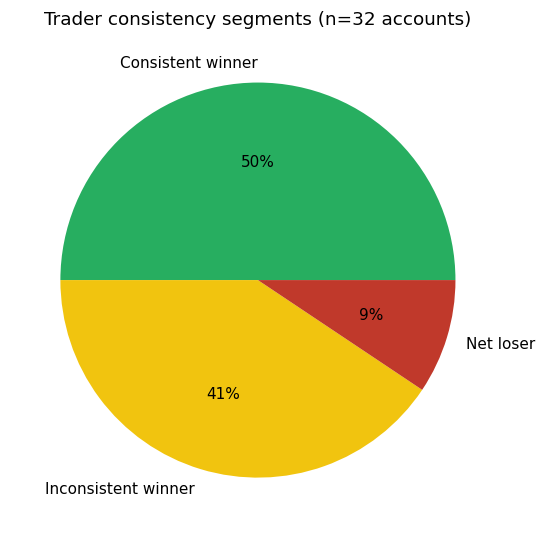

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 5))
counts = acct_summary['consistency_segment'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.0f%%', colors=['#27ae60', '#f1c40f', '#c0392b'])
ax.set_title(f'Trader consistency segments (n={len(acct_summary)} accounts)')
plt.tight_layout(); plt.show()


## Bonus — Behavioral Archetype Clustering (KMeans)

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

ls = acct_day.groupby('Account')['long_short_ratio'].mean().reset_index().rename(
    columns={'long_short_ratio': 'avg_long_short_ratio'})
feat = acct_summary.merge(ls, on='Account', how='left')

feature_cols = ['avg_trade_size', 'avg_daily_trades', 'avg_win_rate', 'pnl_std', 'avg_long_short_ratio']
feat_clean = feat.dropna(subset=feature_cols).copy()

X = StandardScaler().fit_transform(feat_clean[feature_cols])
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
feat_clean['cluster'] = km.fit_predict(X)

profile = feat_clean.groupby('cluster')[feature_cols + ['total_pnl']].mean().round(2)
profile['n_accounts'] = feat_clean.groupby('cluster').size()
display(profile)


         avg_trade_size  avg_daily_trades  ...  total_pnl  n_accounts
cluster                                    ...                       
0               5017.86             99.45  ...  364546.02          11
1               4557.03             60.89  ...  153894.95          13
2               4528.36            756.86  ...  940163.81           1
3              23290.51            137.21  ...  471954.66           7

[4 rows x 7 columns]


In [15]:
size_rank = profile['avg_trade_size'].rank(ascending=False)
freq_rank = profile['avg_daily_trades'].rank(ascending=False)
wr_rank = profile['avg_win_rate'].rank(ascending=False)
vol_rank = profile['pnl_std'].rank(ascending=False)

labels = {}
for c in profile.index:
    tags = [
        'large-size' if size_rank[c] <= k / 2 else 'small-size',
        'high-freq' if freq_rank[c] <= k / 2 else 'low-freq',
        'high win-rate' if wr_rank[c] <= k / 2 else 'lower win-rate',
        'volatile PnL' if vol_rank[c] <= k / 2 else 'steady PnL',
    ]
    labels[c] = ' / '.join(tags)
for c, l in labels.items():
    print(f"Cluster {c}: {l}  (n={int(profile.loc[c, 'n_accounts'])})")


Cluster 0: large-size / low-freq / lower win-rate / steady PnL  (n=11)
Cluster 1: small-size / low-freq / high win-rate / steady PnL  (n=13)
Cluster 2: small-size / high-freq / high win-rate / volatile PnL  (n=1)
Cluster 3: large-size / high-freq / lower win-rate / volatile PnL  (n=7)


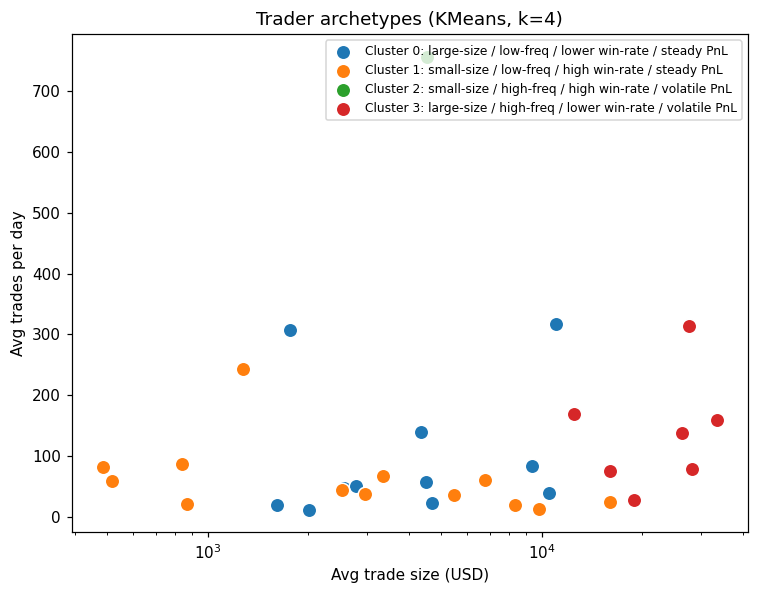

In [16]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cmap = plt.get_cmap('tab10')
for c in sorted(feat_clean['cluster'].unique()):
    sub = feat_clean[feat_clean['cluster'] == c]
    ax.scatter(sub['avg_trade_size'], sub['avg_daily_trades'], s=90,
               color=cmap(c), label=f"Cluster {c}: {labels[c]}", edgecolor='white')
ax.set_xlabel('Avg trade size (USD)'); ax.set_ylabel('Avg trades per day'); ax.set_xscale('log')
ax.set_title('Trader archetypes (KMeans, k=4)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()


**Reading:** four rough archetypes emerge — e.g. a large-size/lower-win-rate/volatile
group that behaves like the "Fear-day beneficiaries" segment above, and a small-size/high
win-rate/steady group that trades more conservatively. One account is a clear outlier
(756 trades/day) and likely reflects automated/algorithmic execution rather than discretionary
trading — worth excluding or treating separately in any production model.

## Part C — Actionable Output

**Strategy idea 1 — Position-size discipline on Fear days, segmented by trader profile.**
The Fear-day PnL premium is concentrated almost entirely in high-notional traders; low-size
traders see no benefit and actually do better on Greed days. Rule of thumb: *if you are a
small-size/low-frequency trader, don't chase size increases on Fear days — the risk/reward
skews against this segment. If you are already a high-size trader, Fear days are where your
edge shows up, but the 5th-percentile drawdown is ~20x deeper than on Greed days, so pair any
size-up with a hard stop-loss or reduced position count.*

**Strategy idea 2 — Cap trade frequency increases during Fear regimes for archetypes with
lower win rates.** Frequent trading amplifies whatever sentiment-driven bias is present —
frequent traders' avg PnL swings ~$3,000+ between Fear and Greed days, vs a much smaller
swing for infrequent traders. For the "large-size / high-freq / lower win-rate / volatile"
cluster specifically, increasing frequency during Fear regimes increases variance without a
corresponding improvement in win rate — a rule of thumb here is *frequency scale-ups during
Fear days should be reserved for clusters with above-median win rates (e.g. the
small-size/high win-rate archetype), not applied uniformly.*


## Limitations & Caveats

- **No leverage/margin data available** — Size USD (notional) is used as a proxy for
  risk-taking, which conflates position size with actual leverage (unknown account equity).
- Only 32 unique accounts are present — segment-level and cluster-level conclusions should
  be treated as directional, not statistically robust, given the small N.
- Sentiment is a single BTC-wide daily label; it is applied uniformly to all 246 traded
  coins even though each may have coin-specific sentiment dynamics.
- "Win rate" and "realized PnL" only count trades where `Closed PnL != 0` (position-closing
  events); pure position-opening trades are excluded since they have no PnL yet.
